# Data Parallelism in PyTorch using nn.DataParallel

In this notebook, we train a neural network using single program multiple data (SPMD) parallelism. This is also known as "data parallelism".

To achieve data parallelism, we simply need to use `torch.DataParallel(model, device_ids=devices)`. However, this mode of data parallelism is no longer encouraged. PyTorch users are now encouraged to use `torch.DistributedDataParallel`. 

`torch.DataParallel` uses single-process, multi-thread (multithreading), while `torch.DistributedDataParallel` uses multi-process (multiprocessing). The benefit of multiprocessing are that the Python Global Interpreter Lock (GIL) doesn't lead to performance bottlenecks. Multi-processing also can be combined with model parallelism, while DataParallel does not integrate well with model parallelism.

In this notebook, we will implement ResNet-18 and use it to train FashionMNIST. For this larger network (compared to the train-from-scratch notebook), the forward and backward passes are the bottleneck and so we should see improved runtime as we scale from 1 GPU to 2 GPUs.

In [2]:
from time import time

import torch
import matplotlib.pyplot as plt
from torch import nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [3]:
assert torch.cuda.is_available()
print(torch.cuda.device_count())

2


### Create model

In [4]:
class Residual(nn.Module):
    def __init__(self, in_channels, out_channels, strides=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 
                               kernel_size=3, padding=1, 
                               stride=strides)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 
                               kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        if in_channels != out_channels:
            self.conv3 = nn.Conv2d(in_channels, out_channels, 
                                   kernel_size=1, stride=strides)
        else:
            self.conv3 = None

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3 is not None:
            X = self.conv3(X)
        return F.relu(X + Y) 

def resnet18(num_classes=10, in_channels=1):
    def resnet_block(in_channels, out_channels, num_residuals):
        blk = []
        for i in range(num_residuals):
            if i == 0 and in_channels != out_channels:
                blk.append(Residual(in_channels, out_channels, strides=2))
            else:
                blk.append(Residual(out_channels, out_channels))
        return nn.Sequential(*blk)
    stem = nn.Sequential(
        nn.Conv2d(in_channels, 32, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(32), 
        nn.ReLU()
    )
    body = nn.Sequential(
        resnet_block(32, 32, 2),
        resnet_block(32, 64, 2),
        resnet_block(64, 128, 2),
        resnet_block(128, 256, 2)
    )
    head = nn.Sequential(
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Linear(256, num_classes)
    )
    return nn.Sequential(stem, body, head)

In [5]:
model = resnet18()
X_test = torch.randn(64, 1, 28, 28)
print(model(X_test).shape)

torch.Size([64, 10])


### Train model

In [6]:
def load_fashion_mnist(batch_size=128):
    train_ds = datasets.FashionMNIST(root='data', transform=transforms.ToTensor(), train=True, download=True)
    val_ds = datasets.FashionMNIST(root='data', transform=transforms.ToTensor(), train=False, download=True)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_dl, val_dl

In [7]:
def loss_fn(X, y, model):
    return F.cross_entropy(model(X), y)

In [8]:
def train_step(
        X: torch.Tensor, y: torch.Tensor, 
        model: nn.Module, opt: torch.optim) -> None:
    loss = loss_fn(X, y, model)
    loss.backward()
    opt.step()
    opt.zero_grad()
    return loss

In [13]:
def train(model, num_gpus=1, batch_size=128, lr=0.1):
    assert torch.cuda.is_available(), "CUDA not available"
    train_dl, _ = load_fashion_mnist(batch_size=batch_size*num_gpus)
    devices = [torch.device(f"cuda:{i}") for i in range(num_gpus)]
    # here is the data parallelism step
    model.to(devices[0])
    model = nn.DataParallel(model, device_ids=devices)
    opt = torch.optim.SGD(model.parameters(), lr)

    num_epochs = 10
    losses = []

    t1 = time()
    for epoch in range(num_epochs):
        print(epoch)
        for X, y in train_dl:
            X, y = X.to(devices[0]), y.to(devices[0])
            loss = train_step(X, y, model, opt)
            losses.append(loss.item())
    t2 = time()
    print(f"{(t2-t1)/num_epochs:.1f} sec/epoch on {devices}")
    return losses

In [10]:
model = resnet18()
losses = train(model, num_gpus=1, batch_size=128, lr=0.1)

0
1
2
3
4
5
6
7
8
9
21.4 sec/epoch on [device(type='cuda', index=0)]


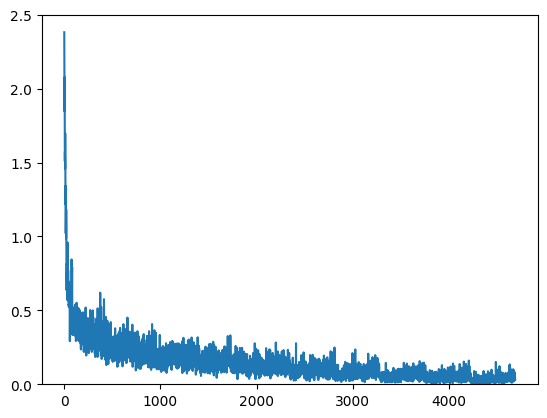

In [11]:
plt.plot(losses)
plt.ylim(bottom=0.0)
plt.show()

In [14]:
model = resnet18()
losses = train(model, num_gpus=2, batch_size=128, lr=0.1)

0
1
2
3
4
5
6
7
8
9
15.8 sec/epoch on [device(type='cuda', index=0), device(type='cuda', index=1)]


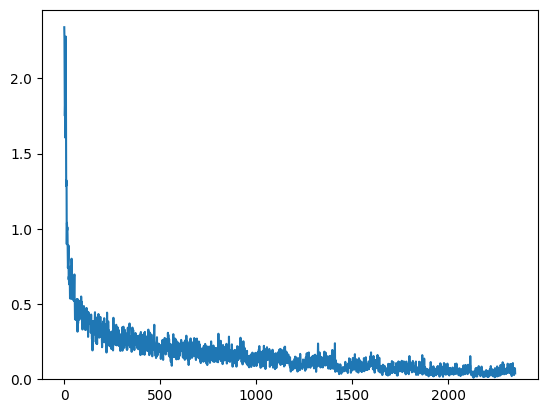

In [15]:
plt.plot(losses)
plt.ylim(bottom=0.0)
plt.show()